In [13]:
import os
from pathlib import Path
from glob import glob
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision # Issues installing... resolved!
import cv2 # Not available from current channels.. resolved - conda-forge FTW

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

It looks like you set device to be `cuda` above, but that's an NVidia thing (I think --- at least it's definitely not a mac thing).  You need to use Metal.  I got it to work on my machine.  

In [8]:
# https://developer.apple.com/metal/pytorch/

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [38]:
device = torch.device('mps') if torch.backends.mps.is_available() else 'cpu'
SEED = 1984

In [24]:
# page 150 of Ayyadevara and Reddy

PATH = Path('.').absolute().parent
data_dir = PATH / 'data' / 'fruits-360_dataset_100x100' / 'fruits-360'
train_data_dir = data_dir / 'Training'
test_data_dir  = data_dir / 'Test'

In [ ]:
class fruits_ds(Dataset):
    def __init__(self, folder, apple_type, orange_type):
        apples  = glob(str(folder) + f'/{apple_type}/*')
        oranges = glob(str(folder) + f'/{orange_type}/*')
        self.fpaths = apples + oranges

        # Randomize file paths and create target variables based on the folder corresponding to these file paths
        from random import shuffle, seed
        seed(SEED)
        shuffle(self.fpaths)
        self.targets = [fpath.split('/')[-1].startswith(orange_type) for fpath in self.fpaths] # Orange = 1
    
    def __len__(self): 
        return len(self.fpaths)

    def __getitem__(self, index):
        f = self.fpaths[index]
        target = self.targets[index]
        im = (cv2.imread(f)[:,:,::-1])
        #im = cv2.resize(im, (224,224))
        return torch.tensor(im/255).permute(2,0,1).float().to(device), \
               torch.tensor([target]).float().to(device)

In [30]:
'./' + folder + '/Apple Braeburn 1/'

TypeError: can only concatenate str (not "PosixPath") to str

In [27]:
apples = glob('./' + folder + '/Apple Braeburn 1/*')
apples

NameError: name 'folder' is not defined

Issue with this now is that 'apples' and 'oranges' are folders not the individual images! 

In [44]:
data = fruits_ds(train_data_dir, 'Apple Braeburn 1', 'Orange 1') #type(data)
data[1]
im, label = data[1]

tensor([0.], device='mps:0')


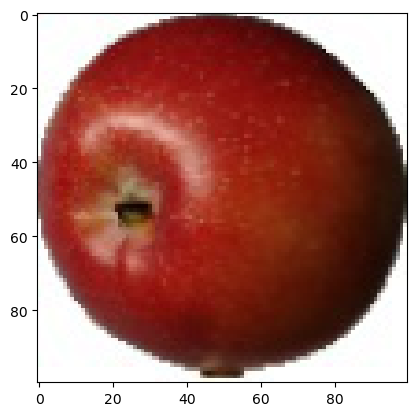

In [46]:
plt.imshow(im.permute(1,2,0).cpu())
print(label)

In [45]:
len(im)
im[:,:, ::-1]

ValueError: step must be greater than zero

In [7]:
folder = train_data_dir
im = cv2.imread(folder + '/Apple Braeburn 1/0_100.jpg')[:,:,::-1]
#im.resize(im, (224,224))

# # Display the image
# cv2.imshow('Image', im)

# # Wait for a key press
# cv2.waitKey(0)

# # Close all windows
# cv2.destroyAllWindows()

In [ ]:
def add_string_to_files(directory, string_to_add, sep = '_'):
    """Adds a string to the beginning of each file in a directory.

    Args:
        directory: The path to the directory containing the files.
        string_to_add: The string to add to each file.
        sep: The string to add after string_to_add (a separator)
    """
    # If the string to add is already there, break out of loop don't want to add it again
    for filename in os.listdir(directory):
        if string_to_add in filename:
            break

        new_name = string_to_add + sep + filename
        os.rename(directory + filename, directory + new_name)

'./fruits-360/Training/Apple Braeburn 1'

In [52]:
folder = train_data_dir
add_string_to_files(directory = './'+folder+'/Apple Braeburn 1/', string_to_add = 'apple')
apples = glob('./' + folder + '/Apple Braeburn 1/*')

add_string_to_files(directory = './'+folder+'/Orange 1/', string_to_add = 'orange')
oranges = glob('./' + folder + '/Orange 1/*')
fpath = apples + oranges
fpath

[]

In [39]:
apples

[]

In [28]:
folder = train_data_dir
apples = glob('./' + folder + '/Apple Braeburn 1/*')

oranges = glob('./' + folder + '/Orange 1/*')
fpath = apples + oranges
fpath

['./fruits-360/Training/Apple Braeburn 1/r_236_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/247_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_226_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/257_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_150_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/121_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_140_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/131_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/198_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/188_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/18_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_132_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/143_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_122_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/153_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_254_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/225_100.jpg',
 './fruits-360/Training/Apple Braeburn 1/r_244_100.j

In [40]:
filepath = train_data_dir + '/Apple Braeburn 1'
os.listdir('./' + filepath)

['r_236_100.jpg',
 '247_100.jpg',
 'r_226_100.jpg',
 '257_100.jpg',
 'r_150_100.jpg',
 '121_100.jpg',
 'r_140_100.jpg',
 '131_100.jpg',
 '198_100.jpg',
 '188_100.jpg',
 '18_100.jpg',
 'r_132_100.jpg',
 '143_100.jpg',
 'r_122_100.jpg',
 '153_100.jpg',
 'r_254_100.jpg',
 '225_100.jpg',
 'r_244_100.jpg',
 '235_100.jpg',
 '300_100.jpg',
 'r_209_100.jpg',
 '278_100.jpg',
 'r_219_100.jpg',
 '310_100.jpg',
 '268_100.jpg',
 'r_25_100.jpg',
 'r_313_100.jpg',
 'r_303_100.jpg',
 '27_100.jpg',
 '11_100.jpg',
 '285_100.jpg',
 '295_100.jpg',
 'r_192_100.jpg',
 'r_182_100.jpg',
 'r_13_100.jpg',
 'r_149_100.jpg',
 '138_100.jpg',
 'r_159_100.jpg',
 '128_100.jpg',
 '181_100.jpg',
 '191_100.jpg',
 'r_296_100.jpg',
 'r_286_100.jpg',
 '2_100.jpg',
 'r_272_100.jpg',
 '203_100.jpg',
 'r_262_100.jpg',
 '213_100.jpg',
 'r_114_100.jpg',
 '165_100.jpg',
 'r_104_100.jpg',
 '175_100.jpg',
 'r_176_100.jpg',
 '107_100.jpg',
 'r_166_100.jpg',
 '117_100.jpg',
 'r_210_100.jpg',
 '319_100.jpg',
 '261_100.jpg',
 '309_100

/Users/trobacker/ml_projects/Projects/ImageClassification


In [24]:
apples = glob(train_data_dir + '/Apple Braeburn 1')
print(apples)

[]


In [26]:
type(apples)

list